In [2]:
# Install libraries
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn

# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
# Load data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
df.head()          # see first 5 rows
df.shape           # how many rows and columns
df.info()          # data types
df.describe()      # statistics
df.isnull().sum()  # check missing values

# Check how many churned vs stayed
df['Churn'].value_counts()
# Output:
# No     5174
# Yes    1869

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


In [4]:
# Fix missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop columns you don't need
df.drop('customerID', axis=1, inplace=True)

# Convert Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_987/2886090779.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [5]:
# Convert text columns to numbers
label_encoder = LabelEncoder()

text_columns = ['gender', 'Partner', 'Dependents',
                'PhoneService', 'Contract', 'PaymentMethod']

for col in text_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [6]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)  # everything except Churn
y = df['Churn']               # only Churn column

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 5634
Testing samples: 1409


In [8]:
# Fix 1 — Convert Churn column to numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Fix 2 — Convert TotalCharges to number (common issue)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fix 3 — Drop any NaN values created
df.dropna(inplace=True)

# Fix 4 — Encode ALL other text columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

text_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Text columns found:", text_columns)

for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

print("All columns are now numbers ✅")
print(df.dtypes)

Text columns found: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
All columns are now numbers ✅
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines       float64
InternetService     float64
OnlineSecurity      float64
OnlineBackup        float64
DeviceProtection    float64
TechSupport         float64
StreamingTV         float64
StreamingMovies     float64
Contract              int64
PaperlessBilling    float64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn               float64
dtype: object


In [10]:
# Check which columns still have text
print(X_train.dtypes)
print("\nAny object columns?")
print(X_train.select_dtypes(include=['object']).columns.tolist())

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract              int64
PaperlessBilling     object
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object

Any object columns?
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Fix every text column in X_train and X_test
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(f"Fixing column: {col}")
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

print("\nAll fixed! Dtypes now:")
print(X_train.dtypes)

Fixing column: MultipleLines
Fixing column: InternetService
Fixing column: OnlineSecurity
Fixing column: OnlineBackup
Fixing column: DeviceProtection
Fixing column: TechSupport
Fixing column: StreamingTV
Fixing column: StreamingMovies
Fixing column: PaperlessBilling

All fixed! Dtypes now:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Now both classes are equal
print(y_train_balanced.value_counts())
# 0    4000
# 1    4000

Churn
0    4138
1    4138
Name: count, dtype: int64


In [16]:
# Model 1 — Logistic Regression (simple baseline)
lr = LogisticRegression()
lr.fit(X_train_balanced, y_train_balanced)

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# Model 3 — XGBoost (usually best for this type of problem)
xgb_model = xgb.XGBClassifier(
    n_estimators=300,      # zyada trees
    max_depth=6,           # tree kitna deep ho
    learning_rate=0.05,    # dheere dheere seekhe
    scale_pos_weight=3,    # churned class ko zyada importance do
    random_state=42
)
xgb_model.fit(X_train_balanced, y_train_balanced)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42),
    params,
    cv=5,
    scoring='recall'
)
grid.fit(X_train_balanced, y_train_balanced)

print("Best params:", grid.best_params_)

# Ab best model se predict karo
best_model = grid.best_estimator_
y_pred_new = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1036
           1       0.53      0.80      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [21]:
y_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import recall_score, precision_score

print("Threshold → Recall   Precision")
print("-" * 35)
for thresh in [0.30, 0.35, 0.40, 0.45, 0.50]:
    y_temp = (y_prob >= thresh).astype(int)
    r = recall_score(y_test, y_temp)
    p = precision_score(y_test, y_temp)
    print(f"  {thresh}    →  {r:.2f}     {p:.2f}")

Threshold → Recall   Precision
-----------------------------------
  0.3    →  0.93     0.44
  0.35    →  0.92     0.46
  0.4    →  0.88     0.48
  0.45    →  0.84     0.50
  0.5    →  0.80     0.53


              precision    recall  f1-score   support

           0       0.95      0.61      0.74      1036
           1       0.46      0.92      0.61       373

    accuracy                           0.69      1409
   macro avg       0.71      0.76      0.68      1409
weighted avg       0.82      0.69      0.71      1409

ROC-AUC: 0.76


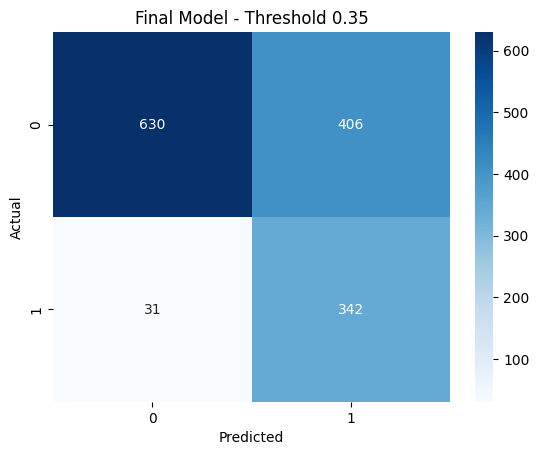

In [23]:
# Threshold 0.35 wala final prediction
y_prob = best_model.predict_proba(X_test)[:, 1]
y_final = (y_prob >= 0.35).astype(int)

# Report
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_final):.2f}")

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Model - Threshold 0.35')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

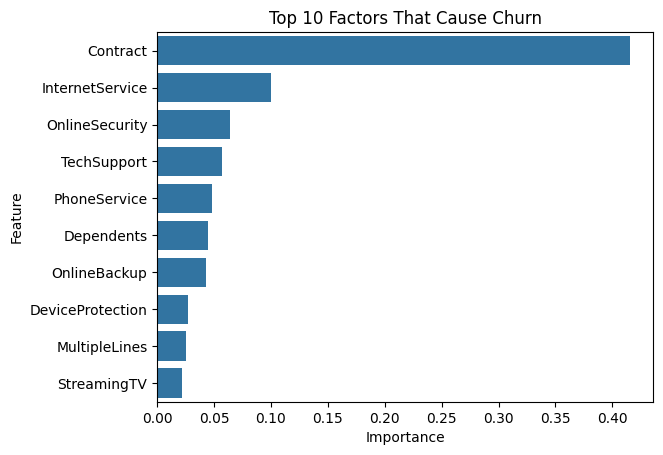

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot it
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title('Top 10 Factors That Cause Churn')
plt.show()

In [24]:
import joblib
joblib.dump(best_model, 'churn_model.pkl')
print("Model saved! ✅")

Model saved! ✅


In [25]:
from google.colab import drive, files
drive.mount('/content/drive')

# Drive mein bhi save karo
joblib.dump(best_model, '/content/drive/MyDrive/churn_model.pkl')

# Laptop pe bhi download karo
joblib.dump(best_model, 'churn_model.pkl')
files.download('churn_model.pkl')

print("Dono jagah save ho gaya! ✅")

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dono jagah save ho gaya! ✅


In [ ]:
# wapas kabhi use krna ho toh# Wapas load karo
# import joblib
# model = joblib.load('/content/drive/MyDrive/churn_model.pkl')

# # Predict karo
# prediction = model.predict(new_data)